# **E-news Express Project**

# **Problem Definition**


The problem definition in this case revolves around assessing the effectiveness of a newly designed landing page in gathering new subscribers for E-news Express, an online news portal. The company have observed a decline in new monthly subscribers and attribute it to the current webpage's inadequate design in terms of outline and recommended content, which fails to engage users long enough to convert them into subscribers.

To address this problem, the design team has created a new landing page with an updated outline and more relevant content. The aim is to test the effect of the new landing page compared to the existing one.

**The key questions to be answered through statistical analysis are:**



*   Do users spend more time on the new landing page than on the existing landing page?

*   Is the conversion rate for the new landing page greater than the conversion rate for the old landing page?

*   Does the converted status depend on the preferred language?

*   Is the time spent on the new landing page the same for users of different language preferences?


By addressing these questions, the main goal is to provide insights and recommendations to optimize user engagement and increase new subscribers for E-news Express.

In [2]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Library to help with statistical analysis
import scipy.stats as stats

In [4]:
#Load and Read the CSV file from Drive

df=pd.read_csv('/content/drive/MyDrive/GL_AIML/Statistics/Project/abtest.csv')

In [3]:
# Check the structure of the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    int64  
 1   group                   100 non-null    object 
 2   landing_page            100 non-null    object 
 3   time_spent_on_the_page  100 non-null    float64
 4   converted               100 non-null    object 
 5   language_preferred      100 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.8+ KB


In [5]:
# Check the first five rows of the dataset

df.head()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


In [5]:
# Check for missing values

df.isnull().sum()

user_id                   0
group                     0
landing_page              0
time_spent_on_the_page    0
converted                 0
language_preferred        0
dtype: int64

In [7]:
# Lets describe the data set

df.describe()

,user_id,time_spent_on_the_page
count,100.000000,100.000000
mean,546517.000000,5.377800
std,52.295779,2.378166
min,546443.000000,0.190000
25%,546467.750000,3.880000
50%,546492.500000,5.415000
75%,546567.250000,7.022500
max,546592.000000,10.710000


### **Define the problem and perform an Exploratory Data Analysis**

**Univariate Analysis: We'll analyze each variable individually to understand its distribution.**

**Bivariate Analysis: We'll explore relationships between variables.**

**We will start with EDA (Exploratory Data Analysis)**

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
# Understanding the shape of the dataset

df.shape

(100, 6)

<function matplotlib.pyplot.show(close=None, block=None)>

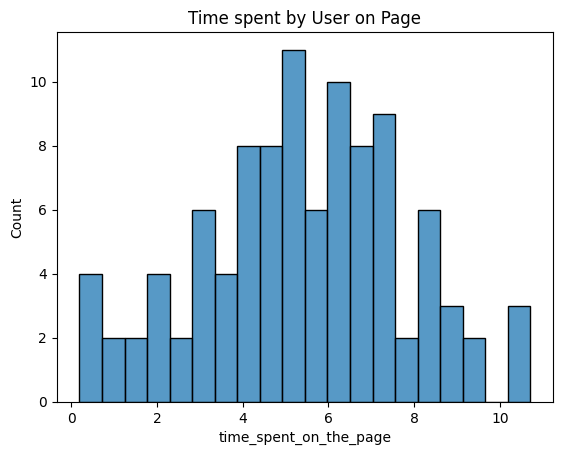

In [18]:
# Visualization of time spent on the page

#sns.histplot(data=df, x = 'time_spent_on_the_page', bins = 20)
#plt.show
sns.histplot(df['time_spent_on_the_page'], bins = 20)
plt.title('Time spent by User on Page')
plt.xlabel('time_spent_on_the_page')
plt.show

In [19]:
df.head(2)

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English


<function matplotlib.pyplot.show(close=None, block=None)>

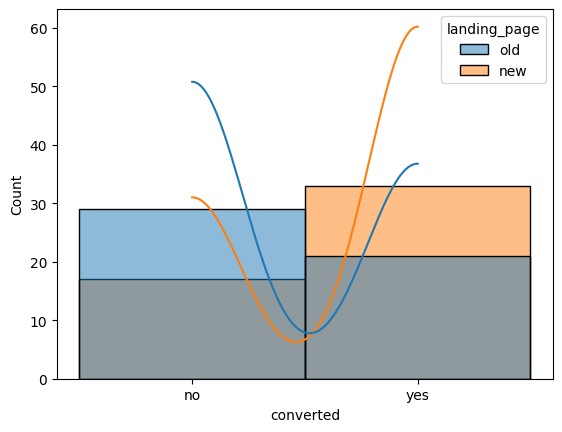

In [29]:
#Rate of conversion with Landing page


sns.histplot(data=df, x='converted', bins = 10, hue='landing_page', kde='yes')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

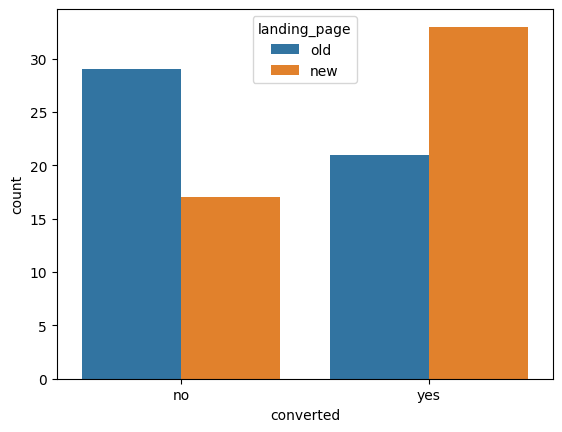

In [32]:
sns.countplot(data=df, x='converted',  hue='landing_page')
plt.show

# **Bivariate analysis**

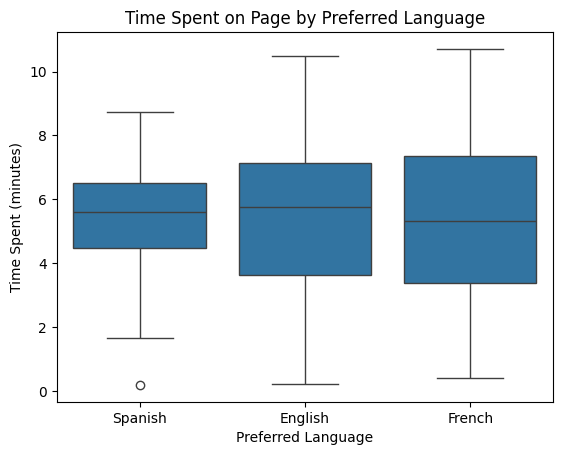

In [33]:
# Time Spent on Page by Preferred Language
sns.boxplot(x='language_preferred', y='time_spent_on_the_page', data=df)
plt.title('Time Spent on Page by Preferred Language')
plt.xlabel('Preferred Language')
plt.ylabel('Time Spent (minutes)')
plt.show()

From above result , we can say that time spent on French and English is more than Spanish

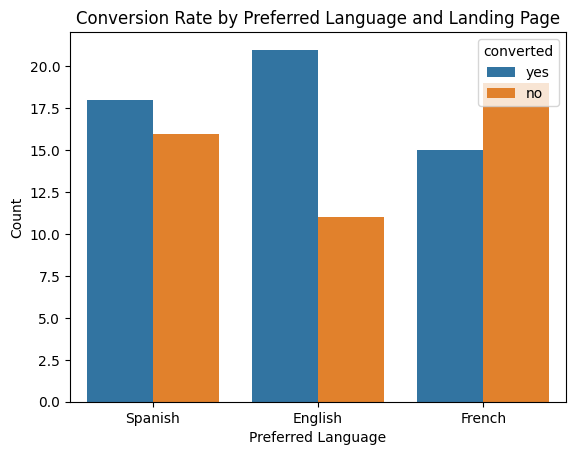

In [35]:
# Conversion Rate by Preferred Language and Landing Page

sns.countplot(x='language_preferred', hue='converted', data=df, hue_order=['yes', 'no'])
plt.title('Conversion Rate by Preferred Language and Landing Page')
plt.xlabel('Preferred Language')
plt.ylabel('Count')
plt.show()

As per above result , we can say that conversion rate by prefferred language is positive in Spanish and English

# **We have completed the Univariate and Bivariate Analysis, now we will have to go for hypothesis testing and statistical analysis**

# ***Hypothesis Testing Case 1 - Do the users spend more time on the new landing page than the old landing page?***

Null Hypothesis: H0: The mean time spent on the new landing page is equal to or less than the mean time spent on the old landing page.

Alternate Hypothesis: H1: The mean time spent on the new landing page is greater than the mean time spent on the old landing page.

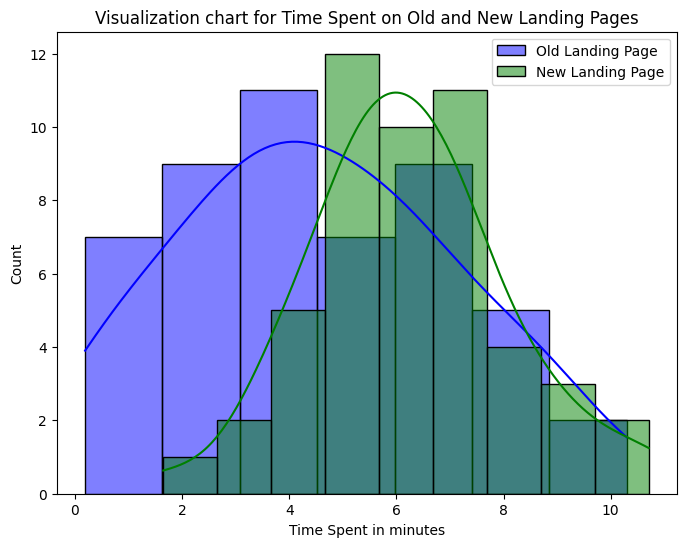

In [71]:
#Visual Analysis

plt.figure(figsize=(8, 6))
sns.histplot(data=df[df['landing_page'] == 'old'], x='time_spent_on_the_page', kde=True, color='blue', label='Old Landing Page')
sns.histplot(data=df[df['landing_page'] == 'new'], x='time_spent_on_the_page', kde=True, color='green', label='New Landing Page')
plt.title('Visualization chart for Time Spent on Old and New Landing Pages')
plt.xlabel('Time Spent in minutes')
plt.ylabel('Count')
plt.legend()
plt.show()


From Visual analysis we can see that mean time spent on the new landing page is greater than the mean time spent on the old landing page.

For more accuracy we will calculate p-value in our next step.

In [38]:
#Calculation of p-value

from scipy import stats



In [143]:
# Separate the data for the old and new landing pages


old_time = df[df['landing_page'] == 'old']['time_spent_on_the_page']
new_time = df[df['landing_page'] == 'new']['time_spent_on_the_page']

#Performing the independent t-test
t_statistic, p_value = stats.ttest_ind(new_time, old_time, alternative='greater')

# Printing Calculated p-value
print('p-value', p_value)

p-value 0.0001316123528095005


As per the case study, the  chosen significance level is 0.05 and we are getting p value is way lesser that the significance level.

Hence, we reject the null hypothesis that The mean time spent on the new landing page is equal to or less than the mean time spent on the old landing page.

As per result we accept alternative hypothesis that The mean time spent on the new landing page is greater than the mean time spent on the old landing page.

# **Hypothesis Test - 2 : Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?**

Null Hypothesis , H0: The conversion rate for the new landing page is lesser than or equal to the conversion rate for the old page.

Alternate Hypothesis, H1: The conversion rate for the new landing page is greater than the conversion rate for the old landing page.

In [10]:
df['converted'].value_counts()

converted
yes    54
no     46
Name: count, dtype: int64

In [25]:
converted_old = df[(df['landing_page'] == 'old') & (df['converted'] == 'yes')].shape[0]
converted_old

total_old = df[(df['landing_page']=='old')].shape[0]
total_old

print(converted_old, total_old)

#converted_old = df[(df['landing_page'] == 'old') & (df['converted'] == 'yes')].shape[0]

21 50


## As per above result, total no of visits on old landing page and total no of converted out of that is 50 and 21 respectively

In [85]:
converted_new = df[(df['landing_page']=='new') & (df['converted'] == 'yes')].shape[0]
converted_new

total_new = df[(df['landing_page']=='new')].shape[0]
total_new
print(converted_new, total_new)

33 50


## As per above result, total no of visits on old landing page and total no of converted out of that is 50 and 33 respectively



*   Since we are comparing proportion from two different samples, we need to perform A one-tailed proportion z-test to reach for a conclusion




<ipython-input-102-8951493fb49d>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Old Landing Page', 'New Landing Page'], y=[converted_old, converted_new], palette='Set2')


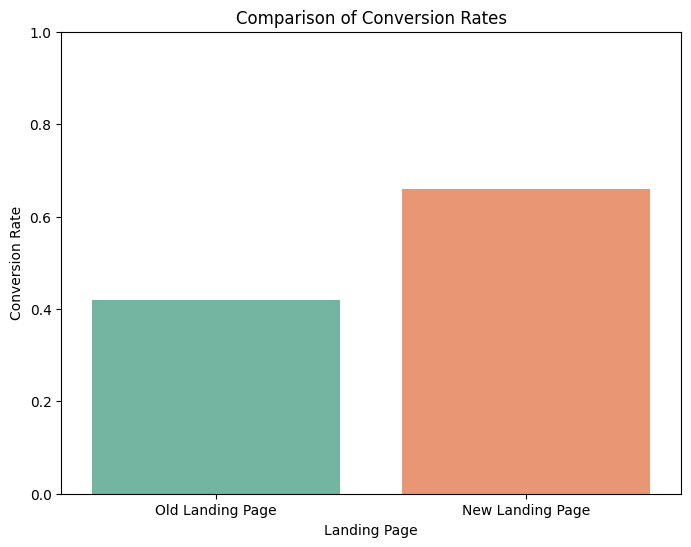

In [102]:
# Visual Analysis

converted_old = df[df['landing_page'] == 'old']['converted'].value_counts(normalize=True)['yes']
converted_new = df[df['landing_page'] == 'new']['converted'].value_counts(normalize=True)['yes']

# Create a bar plot to compare conversion rates
plt.figure(figsize=(8, 6))
sns.barplot(x=['Old Landing Page', 'New Landing Page'], y=[converted_old, converted_new], palette='Set2')

plt.title('Comparison of Conversion Rates')
plt.xlabel('Landing Page')
plt.ylabel('Conversion Rate')
plt.ylim(0, 1)  # Set y-axis limit from 0 to 1 for better visualization

plt.show()

As per the visual analysis we can say that conversion rate on the new landing page is greater than old landing page.

For more accuracy we need to calculate p-value before coming to any conclusion

In [97]:
converted_old = df[(df['landing_page'] == 'old') & (df['converted'] == 'yes')].shape[0]
converted_old

total_old = df[(df['landing_page']=='old')].shape[0]
total_old
print(converted_old, total_old)

converted_new = df[(df['landing_page']=='new') & (df['converted'] == 'yes')].shape[0]
converted_new

total_new = df[(df['landing_page']=='new')].shape[0]
total_new
print(converted_new, total_new)




21 50
33 50


In [95]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

count = [converted_new, converted_old]
nobs = [total_new, total_old]


t, p_value = proportions_ztest(count, nobs, alternative='larger')

print("stats:", t)
print("P-value:", p_value)

stats: 2.4077170617153842
P-value: 0.008026308204056278




*   As per the case study, the chosen significance level is 0.05 and we are getting p value is lesser that the significance level.

*   Hence , We reject the null hypothesis that the conversion rate for the new landing page is lesser than or equal to the conversion rate for the old page.

*   As per result we accept alternative hypothesis that the conversion rate for the new landing page is greater than the conversion rate for the old landing page.




## **Hypothesis Test 3 - Does the converted status depend on the preferred language?**

Here we need to determine whether there is a significant association between two categorical variables or there is any kind of dependency between the two category.

For this we need to perform the Chi-Square test of independence.

Before performing Chi-Square test, we will perform Visual Analysis.


In [105]:
# Create a contingency table

contingency_table = pd.crosstab(df['converted'], df['language_preferred'])
contingency_table

language_preferred,English,French,Spanish
converted,,,
no,11,19,16
yes,21,15,18


<Figure size 1000x600 with 0 Axes>

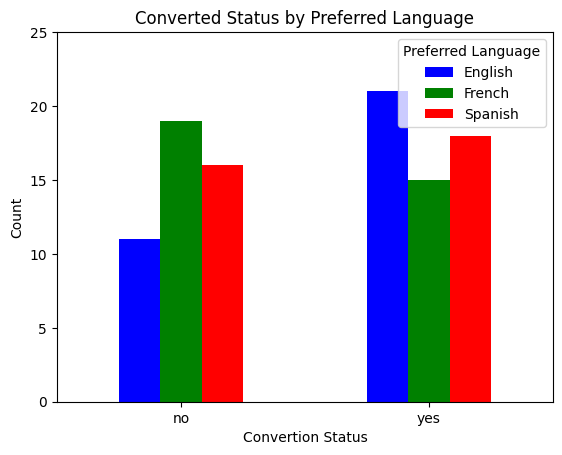

In [117]:
# Cfreating a bar plot
plt.figure(figsize=(10, 6))
contingency_table.plot(kind='bar', color=['blue', 'green', 'red'])
plt.title('Converted Status by Preferred Language')
plt.xlabel('Convertion Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Preferred Language')
plt.ylim(0, 25)  # Set y-axis limit from 0 to 25 for better visualization
plt.show()

As per visual analysis, we can see that the conversion rate is positive in English and Spanish.

For more insights we will be performing chi-square test.

**Hypothesis Testing**



*   Null Hypothesis: H0 - The Variables are dependent.
*   Alternate Hypothesis: H1 - The Variables are not dependent.



In [120]:
import numpy as np
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print('Statistics', chi2)
print('P-value', p_value)
print('Degree of freedom', dof)
print('Expected Frequencies:\n', expected)

Statistics 3.0930306905370837
P-value 0.21298887487543447
Degree of freedom 2
Expected Frequencies:
 [[14.72 15.64 15.64]
 [17.28 18.36 18.36]]


Here p_value is 0.21 which is greater than significance level 0.05. Hence, we cannot reject the null hypothesis and we conclude that converted status is dependent on preffred languages.

## **Hypothesis Test 4 - Is the mean time spent on the new page same for the different language users?**

Null Hypothesis: H0 - The mean time spent on the new landing page is the same for all language users.

Alternate Hypothesis: H1 - The mean time spent on the new landing page is different for atleast one language user group.

<ipython-input-130-16cffdd6a165>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['landing_page'] == 'new'], x='language_preferred', y='time_spent_on_the_page', palette='Set2')


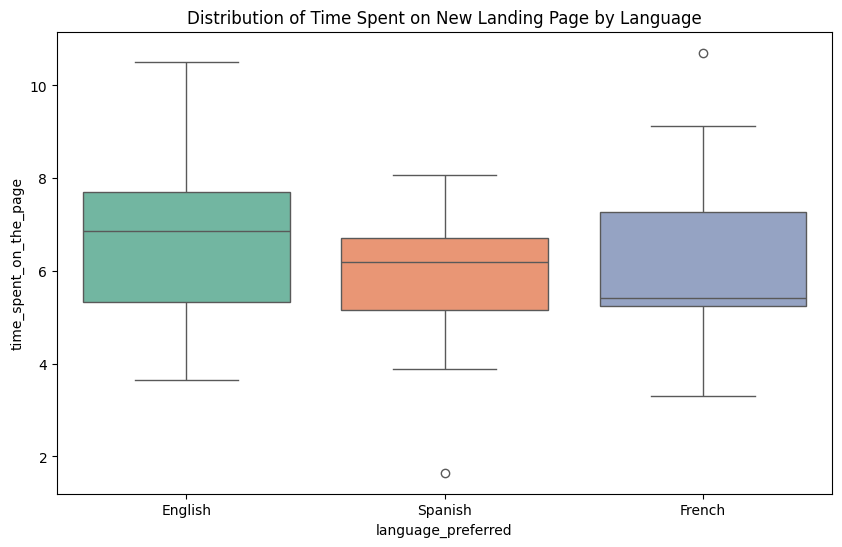

In [130]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[df['landing_page'] == 'new'], x='language_preferred', y='time_spent_on_the_page', palette='Set2')
plt.title('Distribution of Time Spent on New Landing Page by Language')
plt.show()

As per visual analysis we can say that the median time spent is lowest for French users and highest for English users.

We need to calculate p_value to conclude the result.

In [141]:
# Calculating mean time spent for each language

#mu1 = df[df['language_preferred'] == 'English']['time_spent_on_the_page'].mean()
#mu2 = df[df['language_preferred'] == 'Spanish']['time_spent_on_the_page'].mean()
#mu3 = df[df['language_preferred'] == 'French']['time_spent_on_the_page'].mean()

mu1 = df[df['language_preferred'] == 'English']['time_spent_on_the_page']
mu2 = df[df['language_preferred'] == 'French']['time_spent_on_the_page']
mu3 = df[df['language_preferred'] == 'Spanish']['time_spent_on_the_page']

#print('mu1', mu1)
#print('mu2', mu2)
#print('mu3', mu3)

In [145]:
#Perform one way ANOVA Test

from scipy.stats import f_oneway

f_statistic, p_value = f_oneway(mu1, mu2, mu3)

print('statistics', f_statistic)
print('P-value', p_value)






statistics 0.14343439221240437
P-value 0.8665610536012648


As we can see that P-value is greater than the significant value (0.05). Hence, we fail to reject the null hypothesis. There is not enough evidence to suggest that The mean time spent on the new landing page is different for other languages

## **Conclusion and Business Recommendation**

*   Overall the analysis suggests that the redesign of the landing page has been effective in improving user engagement and conversion rates.


*   There may be variations in language preferences among users, these differences do not significantly affect the time spent on the new landing page.

*   It is recommended to continue monitoring behaviour and making iterative improvements to maintain the performance of the landing page.

*   Efforts should be made to ensure that the reading portal is accessible to users across different language preferances.









